In [1]:
# Plot light curve and phase diagram

import matplotlib.pyplot as plt
import numpy as np
from astropy.timeseries import LombScargle
# from scipy import stats
# from scipy.stats import distributions
# import similaritymeasures

In [2]:
#Choose data path

path = '/media/fernando/KINGSTON/Doutorado/2025/reduced/'
date = '20250706'
object = 'V2400Oph'
channel = '4'
source = '33'

data = f'{path}{date}/export_txt'

In [3]:
#   Reading polarimetry data

data1 = np.loadtxt(f'{data}/{object}_ch{channel}_SRC{source}_polar.txt',skiprows=1)

t1=data1[:,0]
mag1=data1[:,2]
mag1_error=data1[:,3]

In [4]:
# Removendo a media dos dados

mag_mean1=np.mean(mag1)
#mag_c1=mag1-mag_mean1
mag_c1=mag1

In [5]:
#data1 = np.loadtxt('11bocet_pol.txt',skiprows=0)

#t2=data1[:,0]
#mag2=data1[:,1]
#mag2_error=data1[:,2]

In [6]:
# Removendo a media dos dados
#
#mag_mean2=np.mean(mag2)
#mag_c2=mag2-mag_mean2
#mag_c2=mag2

In [7]:
#data1 = np.loadtxt('12bocet_pol.txt',skiprows=0)

#t3=data1[:,0]
#mag3=data1[:,1]
#mag3_error=data1[:,2]

In [8]:
# Removendo a media dos dados

#mag_mean3=np.mean(mag3)
#mag_c3=mag3-mag_mean3
#mag_c3=mag3

In [9]:
#data1 = np.loadtxt('19bocet_pol.txt',skiprows=0)

#t4=data1[:,0]
#mag4=data1[:,1]
#mag4_error=data1[:,2]

In [10]:
# Removendo a media dos dados
#
#mag_mean4=np.mean(mag4)
#mag_c4=mag4-mag_mean4
#mag_c4=mag4

In [11]:
time=t1
mag_c=mag_c1
mag_error=mag1_error
#time=np.concatenate((t1,t2,t3,t4))
#mag_c=np.concatenate((mag_c1,mag_c2,mag_c3,mag_c4))
#mag_error=np.concatenate((mag1_error,mag2_error,mag3_error,mag4_error))
# time=1.*t1
# mag_c=1.*mag_c1
# mag_error=1.*mag1_error

In [12]:
#  Filter data
#
filter="no"
# filter="yes"

In [13]:
##### Lomb Scargle
#
# limites em minutos
p1=10.
p2=20.
# 
p1=p1/60./24.0
p2=p2/60./24.0
# 
# limites em dias
# p1=0.
# p2=1.
#
#
# Numero de frequencias
#
n_freq=int(1e6)
frequency = np.linspace(1./p2, 1./p1, n_freq)

In [14]:
#  Fazendo o Lomb-Scargle
#
#ls = LombScargle(time, mag_c)
ls = LombScargle(time, mag_c,mag_error)
power = ls.power(frequency)
probabilities = [0.001]
fap=ls.false_alarm_level(probabilities) 
#
best_frequency = frequency[np.argmax(power)]
best_period=1./best_frequency
print(' ')
print('Best period in days  ', best_period)
print('Best period in hours  ', best_period*24.)
print('Best period in minutes  ', best_period*24.*60.)
print('False alarm probability of 0.001  ',fap)
print(' ')

 
Best period in days   0.010887974907809246
Best period in hours   0.2613113977874219
Best period in minutes   15.678683867245315
False alarm probability of 0.001   [0.05237802]
 


In [15]:
best_period*60*24

15.678683867245315

In [16]:
927/60

15.45

In [17]:
((927.66/60)/60)/24

0.010736805555555555

In [18]:
best_period=((927.66/60)/60)/24

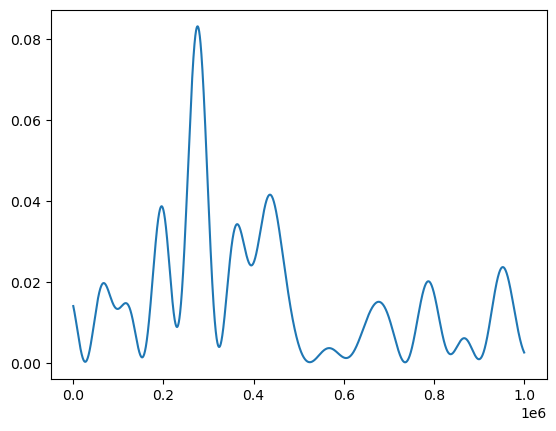

In [19]:
plt.plot(power)

In [20]:
# Calculando phase diagram
#
to=2460863.42808605
phase=((time-to)%best_period)/best_period

In [21]:
phase

array([0.13912096, 0.17432056, 0.20946064, 0.24466336, 0.27982678,
       0.31490012, 0.35001288, 0.3852247 , 0.42040426, 0.45582096,
       0.49101405, 0.52614667, 0.56132666, 0.59645178, 0.63169652,
       0.66684537, 0.70217477, 0.73730258, 0.77243525, 0.80771235,
       0.84286809, 0.87801807, 0.91317498, 0.94823492, 0.98343486,
       0.01875021, 0.05402843, 0.08910229, 0.12421614, 0.15935791,
       0.19450186, 0.22975254, 0.26505124, 0.30030951, 0.33536281,
       0.37051769, 0.40566376, 0.44079855, 0.47598344, 0.51115332,
       0.54633231, 0.58158139, 0.61676793, 0.65189466, 0.68702134,
       0.72216321, 0.75741549, 0.79258642, 0.82779993, 0.86295086,
       0.8982123 , 0.93333955, 0.96853094, 0.00371648, 0.03884373,
       0.07400975, 0.10910356, 0.14463351, 0.17982373, 0.21500437,
       0.25020439, 0.28528051, 0.32056515, 0.35569669, 0.3910924 ,
       0.42632686, 0.46147242, 0.49666494, 0.53183747, 0.56710862,
       0.60229836, 0.63746768, 0.67259493, 0.70796475, 0.74306

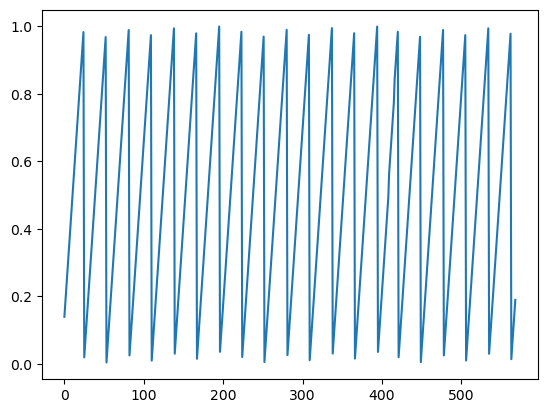

In [22]:
plt.plot(phase)

In [23]:
# Binning data in the best period
#
number_bins=6
center_bin=np.zeros(number_bins)
bin_means=np.zeros(number_bins)
bin_size=1./number_bins
bins = np.linspace(0, 1, number_bins+1)
digitized = np.digitize(phase, bins)
# print(bins)
# print(digitized)

In [24]:
number_bins

6

In [25]:
center_bin

array([0., 0., 0., 0., 0., 0.])

In [26]:
bin_means

array([0., 0., 0., 0., 0., 0.])

In [27]:
bin_size

0.16666666666666666

In [28]:
bins

array([0.        , 0.16666667, 0.33333333, 0.5       , 0.66666667,
       0.83333333, 1.        ])

In [29]:
digitized

array([1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6,
       6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4,
       5, 5, 5, 5, 5, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3,
       3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2,
       2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 6,
       1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5,
       5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4,
       4, 4, 4, 4, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2,
       2, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1,
       1, 1, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6,
       6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4,
       4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 3, 3,
       3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5, 5, 6, 6, 6, 6, 6, 1, 1, 1, 1, 1,
       2, 2, 2, 2, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 5,

In [30]:
for i in range(1, len(bins)):
    im=i-1
    center_bin[im]=bins[i]-0.5*bin_size
    bin_means[im]=np.mean(mag_c[digitized == i])
    print(i,center_bin[im],bin_means[im]) 
#
#    Model sinuosoidal
# 
y_fit = ls.model(time, best_frequency)

1 0.08333333333333333 -8.663756577203126
2 0.25 -8.67404957390737
3 0.4166666666666667 -8.649709070770527
4 0.5833333333333333 -8.621697571602152
5 0.7499999999999999 -8.619410323787097
6 0.9166666666666666 -8.641115652380414


In [31]:
mag_c

array([-8.6256527 , -8.63283378, -8.62939891, -8.62290418, -8.61580009,
       -8.60479557, -8.59618041, -8.59224854, -8.5786849 , -8.56151894,
       -8.54900653, -8.53530902, -8.52218306, -8.51474354, -8.51011461,
       -8.5031488 , -8.50437675, -8.51506645, -8.53042097, -8.55772572,
       -8.58939384, -8.60964974, -8.62525147, -8.63926003, -8.6454174 ,
       -8.64854909, -8.65068903, -8.6387334 , -8.62404055, -8.61454414,
       -8.598936  , -8.57815093, -8.56156834, -8.5417101 , -8.51167475,
       -8.48545133, -8.45681353, -8.43112421, -8.40361311, -8.38553371,
       -8.37898327, -8.38375639, -8.39322032, -8.41315788, -8.43531973,
       -8.4541    , -8.48450908, -8.51073837, -8.52728366, -8.53410337,
       -8.53729331, -8.53988695, -8.5406975 , -8.54430707, -8.55606896,
       -8.5715023 , -8.58557444, -8.60910862, -8.64493595, -8.67458015,
       -8.70005317, -8.71136568, -8.71269722, -8.70453288, -8.68896352,
       -8.6834491 , -8.65081569, -8.61684982, -8.59189491, -8.58

In [32]:
len(mag_c)

569

In [33]:
mag_c[digitized==1]

array([-8.6256527 , -8.64854909, -8.65068903, -8.6387334 , -8.62404055,
       -8.61454414, -8.54430707, -8.55606896, -8.5715023 , -8.58557444,
       -8.60910862, -8.79276677, -8.79282323, -8.78727515, -8.77023824,
       -8.75262628, -8.75456656, -8.73369755, -8.71017997, -8.69238927,
       -8.68383755, -8.77256795, -8.79273014, -8.81216776, -8.82012966,
       -8.698773  , -8.68748114, -8.67767779, -8.66777865, -8.65089521,
       -8.50985597, -8.50017207, -8.50037104, -8.50706904, -8.64863866,
       -8.65989028, -8.6866111 , -8.70915369, -8.72592585, -8.66215152,
       -8.66103311, -8.65692554, -8.65884457, -8.6600832 , -8.5812459 ,
       -8.58706323, -8.59137121, -8.59654573, -8.61113894, -8.63382757,
       -8.6441607 , -8.64865703, -8.65477016, -8.6610837 , -8.61253953,
       -8.62912674, -8.6408076 , -8.65048094, -8.7407332 , -8.73268197,
       -8.71949742, -8.70882773, -8.70316005, -8.57998353, -8.59223589,
       -8.60421925, -8.61070105, -8.71547042, -8.73398285, -8.75

In [34]:
bin_means

array([-8.66375658, -8.67404957, -8.64970907, -8.62169757, -8.61941032,
       -8.64111565])

In [35]:
y_fit

array([-8.68265128, -8.67746327, -8.67133843, -8.66454565, -8.65742499,
       -8.65032378, -8.64355081, -8.63741739, -8.63223827, -8.62823024,
       -8.6256357 , -8.62454873, -8.62501664, -8.62701548, -8.63046447,
       -8.63518112, -8.64098201, -8.64752993, -8.65454725, -8.66173112,
       -8.66868832, -8.67511373, -8.68070597, -8.68518871, -8.68837781,
       -8.69010508, -8.69027607, -8.68889772, -8.68603631, -8.68182361,
       -8.67645991, -8.67017863, -8.66328325, -8.65611852, -8.64905786,
       -8.64237339, -8.63640311, -8.63142869, -8.62767852, -8.62533867,
       -8.62451792, -8.62525892, -8.62752431, -8.6311994 , -8.63611336,
       -8.64203709, -8.6487107 , -8.65578333, -8.6629437 , -8.66983207,
       -8.67615432, -8.681569  , -8.68585261, -8.68879118, -8.69024525,
       -8.6901513 , -8.68851624, -8.68537131, -8.68092774, -8.67537441,
       -8.66896941, -8.662044  , -8.65486036, -8.64783021, -8.64120746,
       -8.63538756, -8.63062581, -8.62712762, -8.62506652, -8.62

In [36]:
len(y_fit)

569

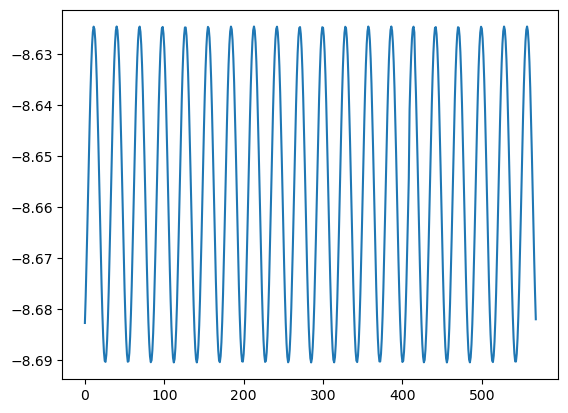

In [37]:
plt.plot(y_fit)

In [38]:
# Filtrando
#
if (filter != "no"):
	f= open("bocet_fot_p1_509.txt","x")
	mag_filtered=np.zeros(len(mag_c))
	for i in range(0, len(mag_c)):
#
#    Aqui eu filtro por media do bin - nao eh bom
#
# 		mag_filtered[i]=mag[i]-bin_means[digitized[i]-1]
#  
#    Aqui filtro por Model sinuosoidal
# 
		mag_filtered[i]=mag_c[i]-y_fit[i]
		f.write(f"{time[i]} {mag_c[i]} {mag_filtered[i]} \n")
	
#
	f.close()

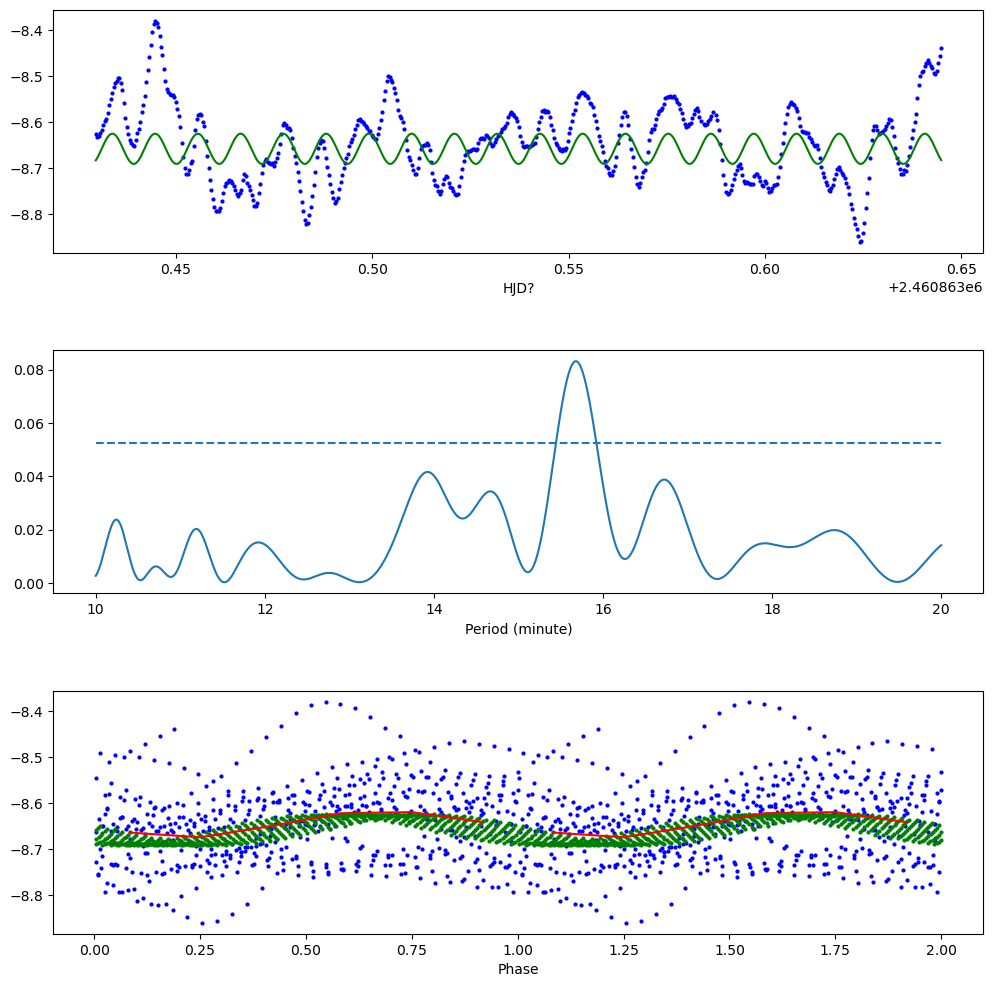

In [39]:
#### Plot

plt.close('all')

#f, ax = plt.subplots(2, sharex=True)
f, ax = plt.subplots(3, figsize=(12, 12), sharex=False)
f.subplots_adjust(hspace=0.4)
#f.align_ylabels(ax[0:1])

ax[0].plot(time,mag_c,'b.',markersize=4)
ax[0].plot(time,y_fit,'g-',markersize=4)
ax[0].set_xlabel('HJD?')
# ax[0].set_xlim(52455.2,52455.4)

ax[1].plot(1./frequency*24.*60.,power)
ax[1].set_xlabel('Period (minute)')
xmin=p1*24.*60.
xmax=p2*24.*60.
# ax[1].plot(1./frequency,power)
# ax[1].set_xlabel('Period (d)')
# xmin=p1
# xmax=p2
ax[1].hlines(fap,xmin,xmax,linestyles='dashed')

ax[2].plot(phase,mag_c,'b.',markersize=4)
ax[2].plot(phase+1.0,mag_c,'b.',markersize=4)
ax[2].plot(phase,y_fit,'g.',markersize=4)
ax[2].plot(phase+1.0,y_fit,'g.',markersize=4)
ax[2].plot(center_bin,bin_means,'r-',markersize=4)
ax[2].plot(center_bin+1.0,bin_means,'r-',markersize=4)
ax[2].set_xlabel('Phase')
# ax[2].set_xlim(0,2)
#ax[2].plot(t_fit,y_fit,'k-')

# print(time.size)
# print(time_b.size)
# print(time_v.size)
plt.show()